# Theory

**Contrast stretching** is a simple image enhancement technique used to improve the contrast in an image by stretching the range of intensity values. In digital images, pixel values typically range from 0 (black) to 255 (white) for 8-bit images. However, due to poor lighting or sensor limitations, the actual range of pixel values in an image may be much narrower, resulting in a low-contrast image.

The contrast stretching operation can be mathematically expressed as:

$$
s = \frac{(r - r_{min})}{(r_{max} - r_{min})} \times 255
$$

where:
- $r$ is the original pixel value,
- $r_{min}$ and $r_{max}$ are the minimum and maximum pixel values in the input image,
- $s$ is the new pixel value after stretching.

This transformation maps the lowest pixel value in the image to 0 and the highest to 255, linearly scaling all other values in between. As a result, the full dynamic range of the display device is utilized, making features in the image more distinguishable.

In the provided code:
- The input image is resized and converted to a NumPy array.
- The minimum and maximum pixel values are found.
- Each pixel is transformed using the contrast stretching formula.
- The original and contrast-stretched images, along with their histograms, are displayed side by side for comparison.



In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
def contrast_stretching(input_image):
  img = input_image.resize((500,500), Image.Resampling.LANCZOS)
  #converitng it to array
  img_array = np.asarray(img)
  min = np.amin(img_array)
  print(min)
  max = np.amax(img_array)
  print(max)
  range = max-min
  row = 400
  column = 400

  array_b = np.zeros((row,column))
  array_b = (((img_array - min)/range)*255)
  min = np.amin(array_b)
  print(min)
  max = np.amax(array_b)
  print(max)
  final_image = Image.fromarray(array_b)
  final_image= final_image.convert("L")





  # set up side-by-side image display
  fig = plt.figure()
  fig.set_figheight(15)
  fig.set_figwidth(15)

  fig.add_subplot(2,2,1)
  plt.imshow(img, cmap='gray')

#Plotting Histogram
  flat = img_array.flatten()
  fig.add_subplot(2,2,3)
  plt.hist(flat, bins=50)




  fig.add_subplot(2,2,2)
  plt.imshow(final_image, cmap='gray')

#Plotting Histogram
  flat2 = array_b.flatten()
  fig.add_subplot(2,2,4)
  plt.hist(flat2, bins=50)




  return final_image


0
255
0.0
255.0


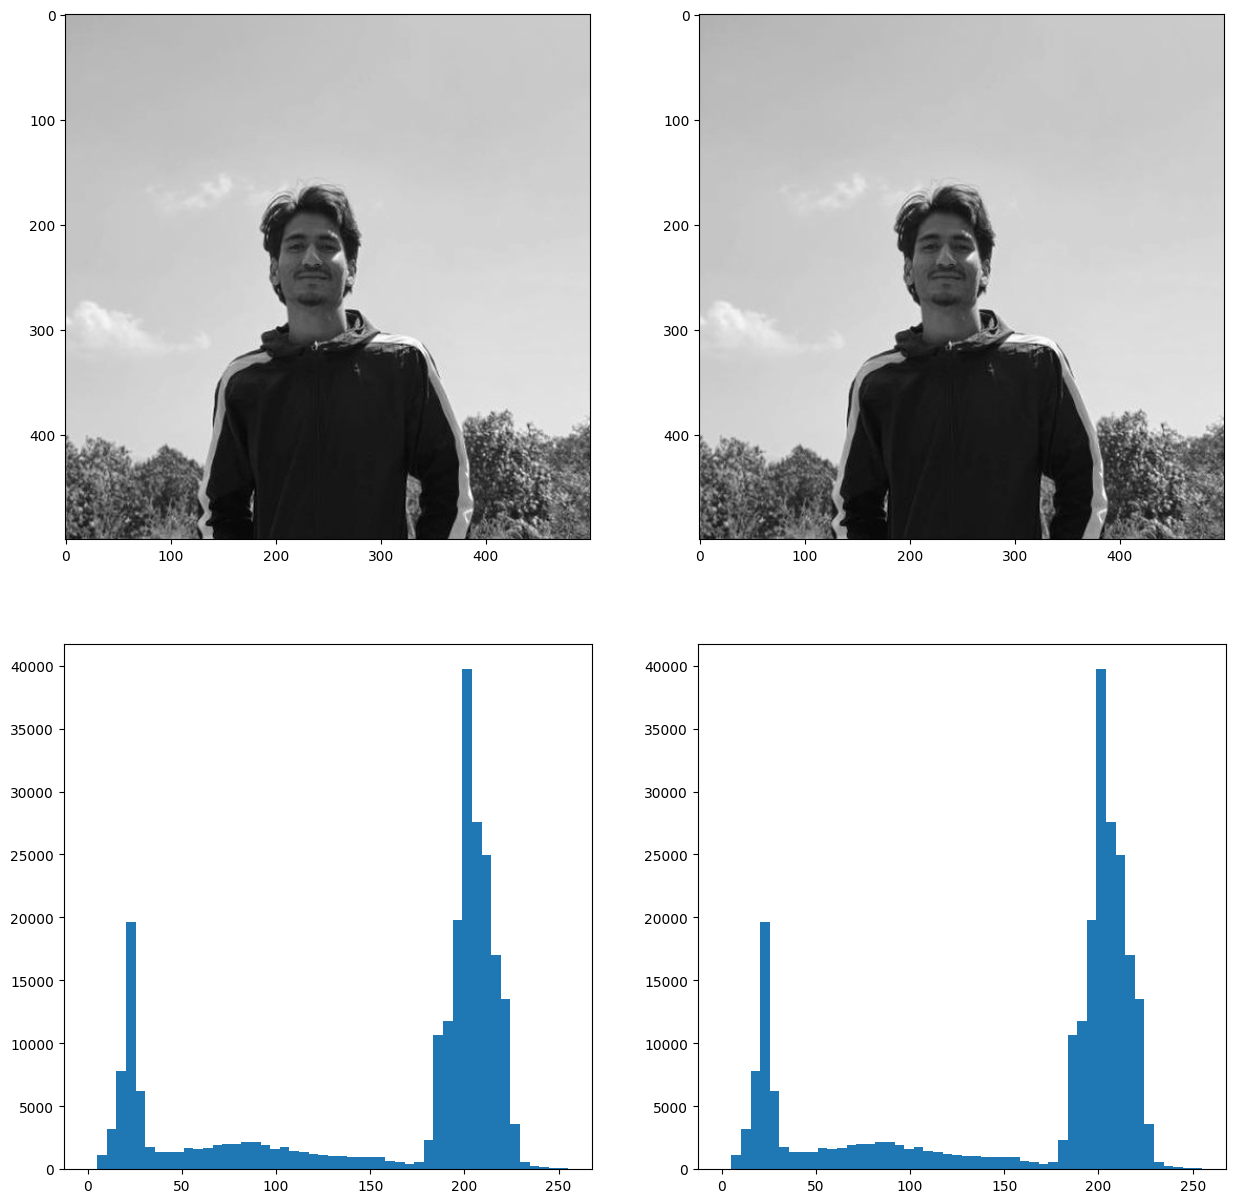

In [3]:
# reading image and converting to gray scale
input_image = Image.open('img/prakash.jpg').convert('L')
a = contrast_stretching(input_image)

# Conclusion

By applying contrast stretching, the image's intensity values are redistributed to span the entire available range. This enhances the visibility of details that were previously hidden in the darker or lighter regions of the image. The histograms before and after stretching clearly show the expansion of pixel value distribution, confirming the effectiveness of the technique. Contrast stretching is a fundamental preprocessing step in image analysis, especially useful for improving the interpretability of images with poor contrast.